## CKD and Diabetes prediction with Explainable AI

### Notebook for the Machine Learning Model for the prediction with XAI

This notebook has the trained Machine Learning Model with the results for Chronic Kidney Disease and Diabetes. Results are not just predictions it has the explanation for the prediction. Prediction are not coming from a blackbox

In [80]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import shap
import lime
import lime.lime_tabular

### Data Import and Pre process

In [81]:
#Importing Dataset

df = pd.read_csv('dataset/kidney_disease.csv')

df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


### Exploratary Data Analysis

Exploring the dataset shape, information about null values and datatypes, and view dataset

In [82]:
#Dataset shape and info

print(df.shape)
print(df.info())
print(df.head())

(400, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-n

Check the missing values and draw a heatmap to identify the missing values. Identify the requiremnt of data removel or pre processing

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


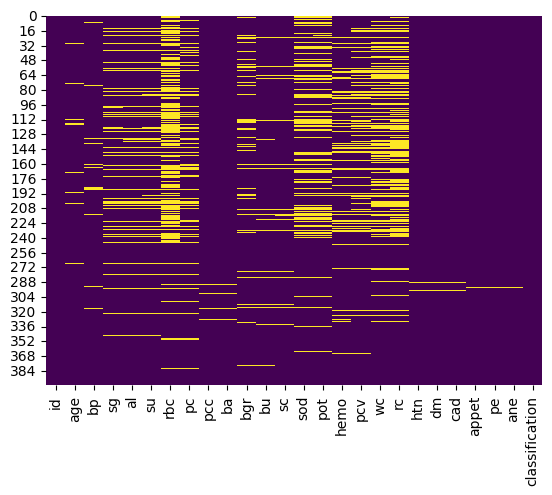

In [83]:
#Check missing values

#gives the total null values
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

Yellow lines indicate that there are missing values in the columns. Since this dataset have many missing values, need to fill or remove missing values before training the model.

Explorer about the categorical and numerical values and identify the requirement of data encoding.

In [84]:
#Data type "object" represent the categorical features

for col in df.select_dtypes(include=['object']).columns:
    print(df[col].value_counts())

rbc
normal      201
abnormal     47
Name: count, dtype: int64
pc
normal      259
abnormal     76
Name: count, dtype: int64
pcc
notpresent    354
present        42
Name: count, dtype: int64
ba
notpresent    374
present        22
Name: count, dtype: int64
pcv
41      21
52      21
44      19
48      19
40      16
43      14
45      13
42      13
28      12
32      12
36      12
33      12
50      12
34      11
37      11
46       9
35       9
29       9
30       9
31       8
39       7
24       7
26       6
38       5
54       4
47       4
53       4
49       4
51       4
22       3
27       3
25       3
19       2
23       2
16       1
\t?      1
17       1
18       1
14       1
15       1
20       1
21       1
9        1
\t43     1
Name: count, dtype: int64
wc
9800    11
6700    10
9200     9
9600     9
7200     9
        ..
9900     1
5900     1
5200     1
9700     1
5100     1
Name: count, Length: 92, dtype: int64
rc
5.2    18
4.5    16
4.9    14
4.7    11
3.9    10
4.8    10
3.4    

We can use Label encoding to convert these categorical variables to numerical

In [85]:
print(df.describe())

               id         age          bp  ...         sod         pot        hemo
count  400.000000  391.000000  388.000000  ...  313.000000  312.000000  348.000000
mean   199.500000   51.483376   76.469072  ...  137.528754    4.627244   12.526437
std    115.614301   17.169714   13.683637  ...   10.408752    3.193904    2.912587
min      0.000000    2.000000   50.000000  ...    4.500000    2.500000    3.100000
25%     99.750000   42.000000   70.000000  ...  135.000000    3.800000   10.300000
50%    199.500000   55.000000   80.000000  ...  138.000000    4.400000   12.650000
75%    299.250000   64.500000   80.000000  ...  142.000000    4.900000   15.000000
max    399.000000   90.000000  180.000000  ...  163.000000   47.000000   17.800000

[8 rows x 12 columns]


From the above description, we can see that some data are in the ranges 0-200, 0-100, 0-50

To get a maximum throughput we can normalize the data if it have a different ranges

Distribution of important features

C:\Users\Anushka\AppData\Local\Temp\ipykernel_19248\861191877.py:10: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


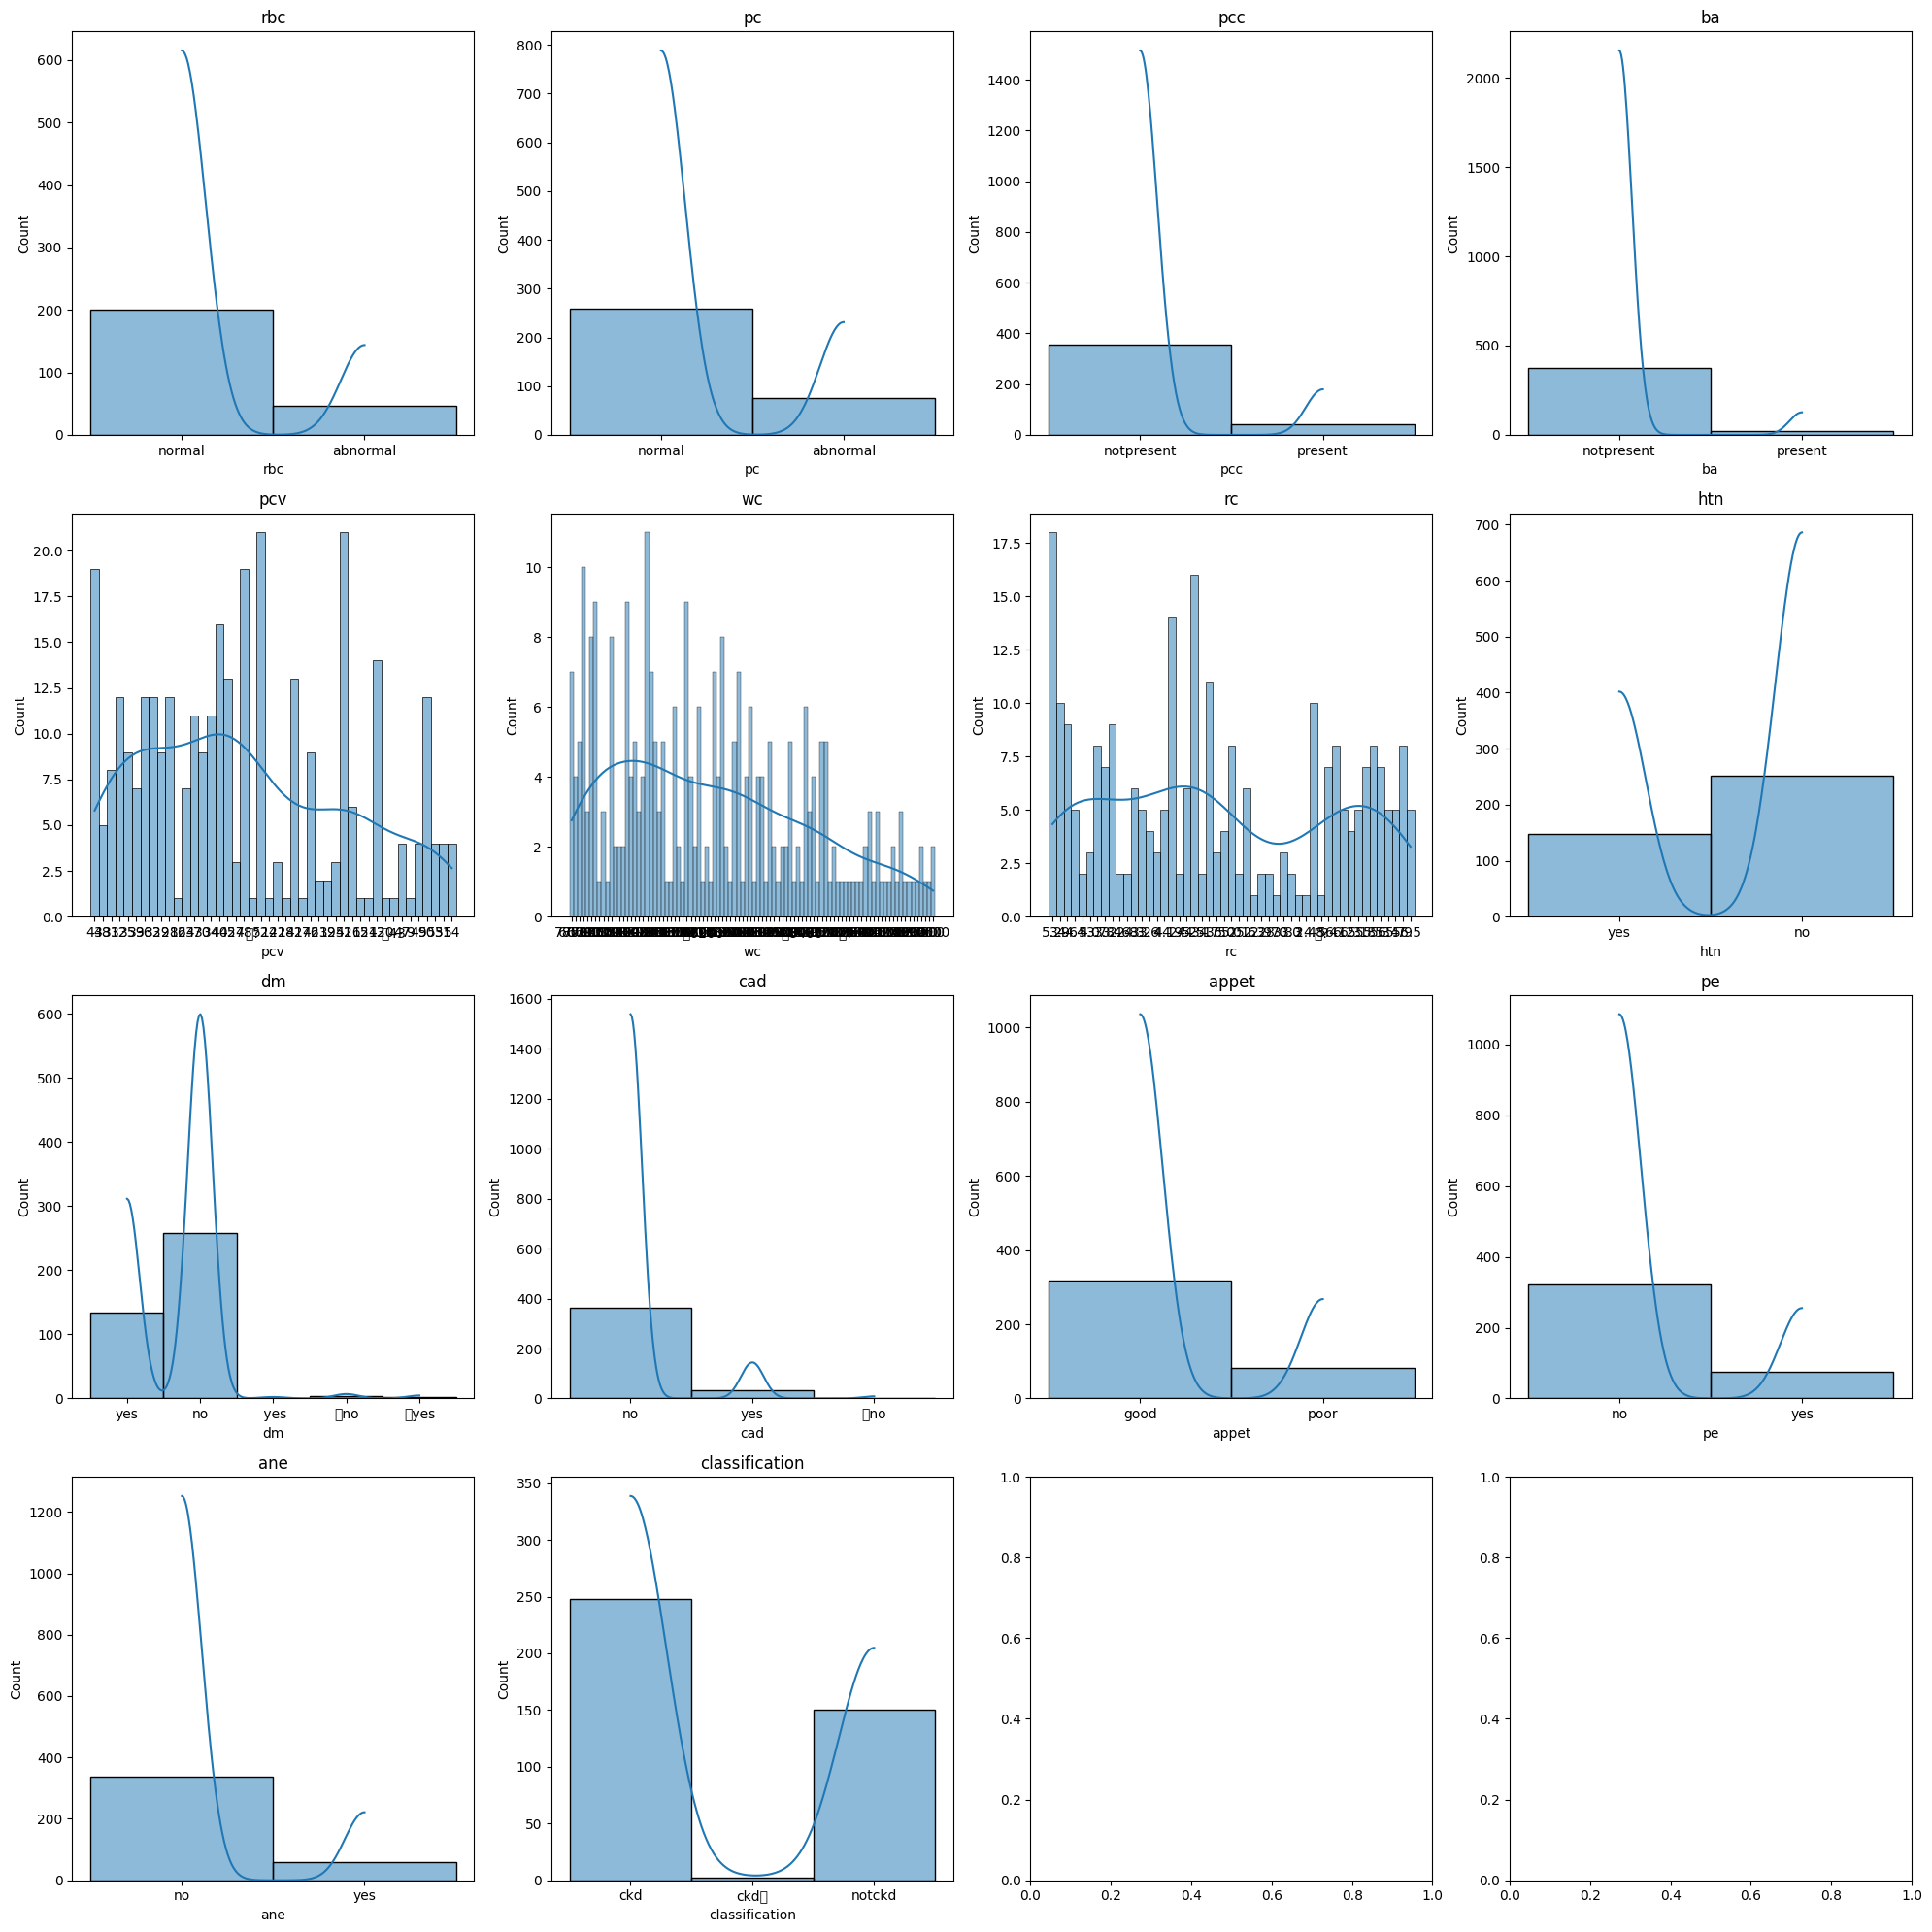

In [86]:
#Distribution of categorical features
fig, axes = plt.subplots(4,4, figsize=(20, 20))

cols = df.select_dtypes(include=['object']).columns

for i, (col, axis) in enumerate(zip(cols, axes.flatten())):
    sns.histplot(data=df, x=col, kde=True, ax=axis)
    axis.set_title(col)

plt.tight_layout()
plt.show()

Explore the correlations between features

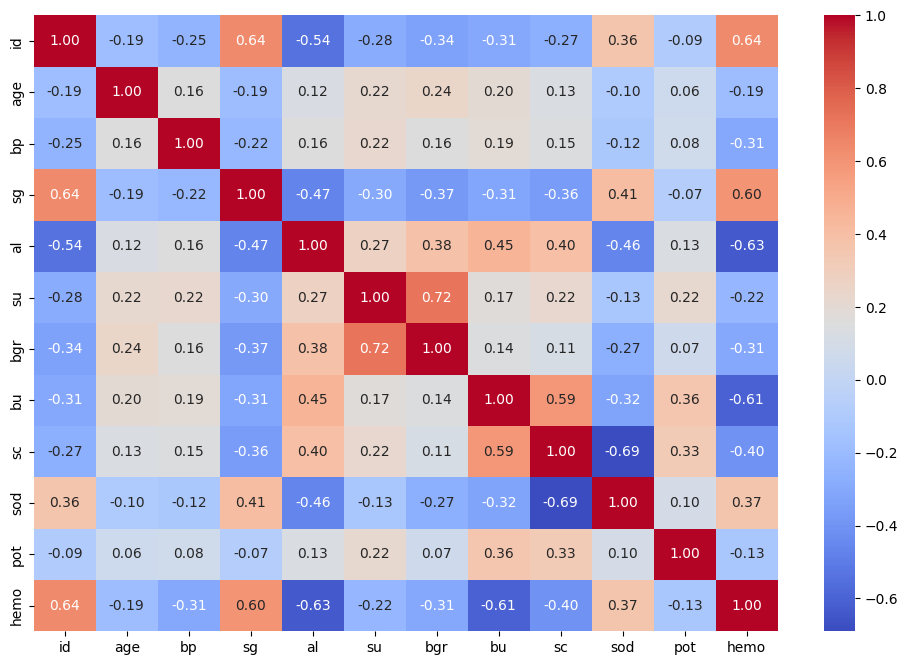

In [87]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Explore the relationship between features and targets

d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


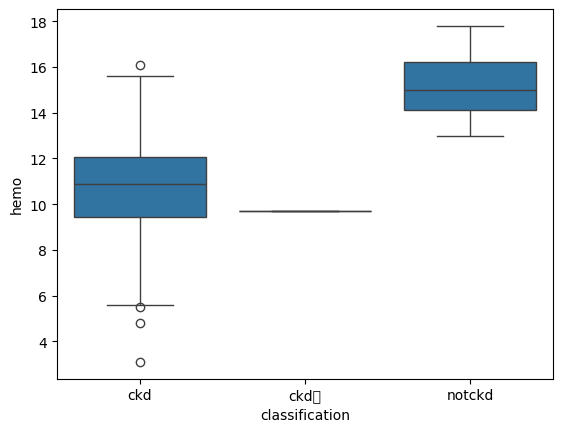

d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


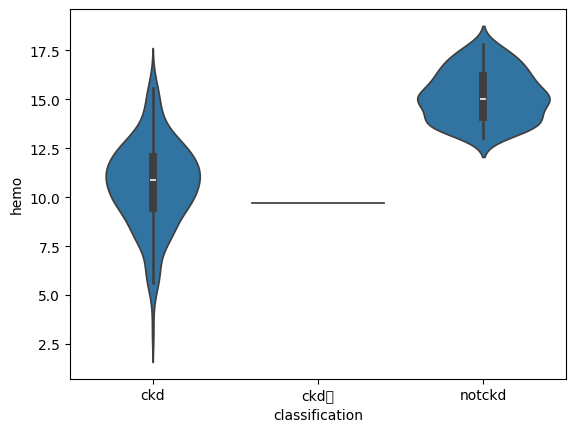

In [88]:
sns.boxplot(x='classification', y='hemo', data=df)
plt.show()

sns.violinplot(x='classification', y='hemo', data=df)
plt.show()

Check the dataset inbalances

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


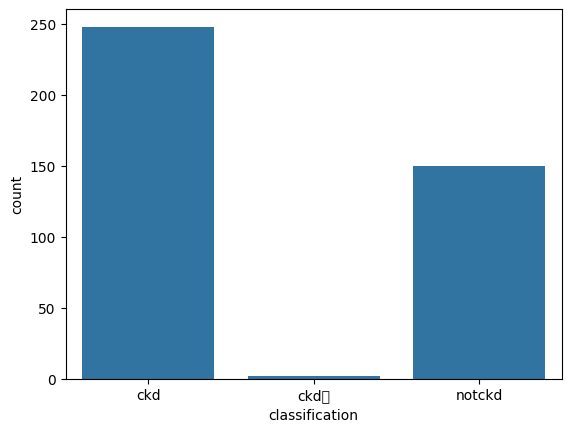

In [89]:
print(df["classification"].value_counts())
sns.countplot(x='classification', data=df)
plt.show()

There is not much inbalance between the dataset

### Data preprocess

In [90]:
#Replacing '?' with NaN
df.replace('?', np.nan, inplace=True)

#convert columns to numeric 
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

#drop rows with too many missing values
df = df.dropna()

# #Filling missing values with mean for numerical columns
# for col in df.select_dtypes(include=[np.number]).columns:
#     df[col].fillna(df[col].mean(), inplace=True)

#Encode the categorical variables
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("classification", axis=1)
y = df["classification"]

#Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42,stratify=y)

#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\Anushka\AppData\Local\Temp\ipykernel_19248\1002087248.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [91]:
print(df.shape)
print(df.info())
print(df.head())

(158, 26)
<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 3 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              158 non-null    int64  
 1   age             158 non-null    float64
 2   bp              158 non-null    float64
 3   sg              158 non-null    float64
 4   al              158 non-null    float64
 5   su              158 non-null    float64
 6   rbc             158 non-null    int64  
 7   pc              158 non-null    int64  
 8   pcc             158 non-null    int64  
 9   ba              158 non-null    int64  
 10  bgr             158 non-null    float64
 11  bu              158 non-null    float64
 12  sc              158 non-null    float64
 13  sod             158 non-null    float64
 14  pot             158 non-null    float64
 15  hemo            158 non-null    float64
 16  pcv             158 non-null    int64  
 17  wc              158 non-null  

All the missing values of the dataset has been removed and the dataset is normalized

### Train the base model

In [92]:
#Train a random forest classifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC: ", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        47

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64

ROC AUC:  1.0


#### Use a simple logistic regression model to check about the dataset 

In [94]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
print(classification_report(y_test, log_reg.predict(X_test)))
print("ROC AUC: ", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        47

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64

ROC AUC:  1.0


I used two models, Random Forest and Logistic Regression. Both gives 100% accuracy for 80% train and 20% test split, and 60% train and 40% test splits. This means the dataset is easy

## XAI Implementation

### SHAP Explainer for the Random Forest model

(64, 25, 2)
(64, 25, 2)
shap_values shape: (64, 25, 2)
X_test shape: (64, 25)


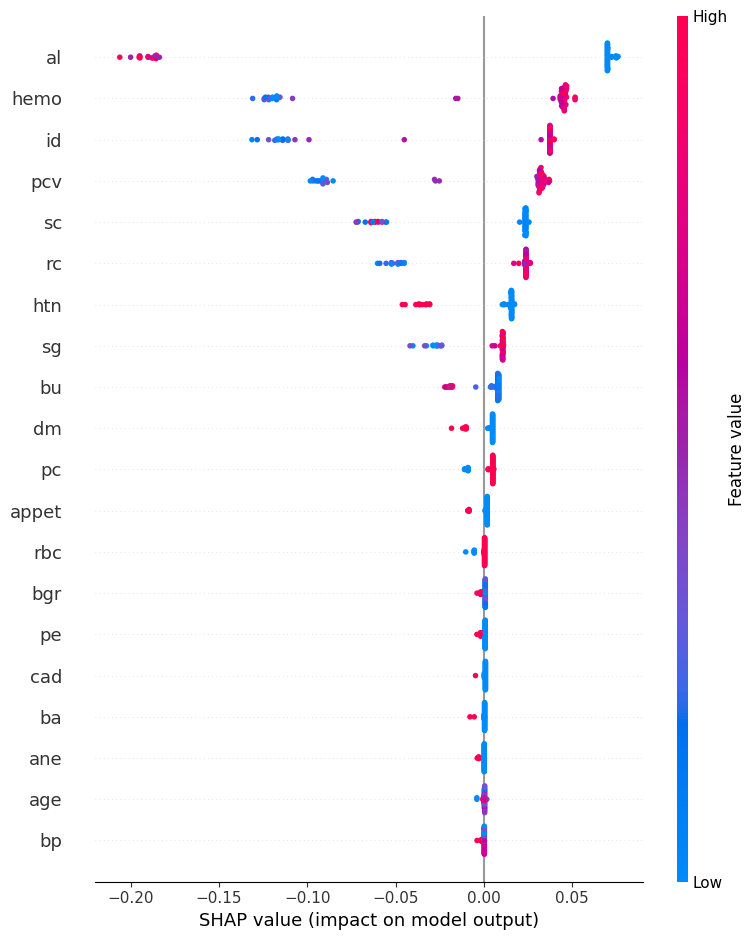

In [118]:
shap.initjs()

#SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(shap_values.shape)

if isinstance(shap_values, list):
    print([arr.shape for arr in shap_values])
else:
    print(shap_values.shape)

print("shap_values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

#Since this is a 3D array
shap.summary_plot(shap_values[:,:,1], X_test, feature_names=X.columns)

i=0
shap.force_plot(explainer.expected_value[1],
                shap_values[i, :, 1],
                X_test.iloc[i])




### Lime Explainer

### Lime Explainer for the Random Forest model

In [126]:
from IPython.display import display, HTML

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['No CKD', 'CKD'],
    mode='classification'
)

i=0
exp = lime_explainer.explain_instance(X_test.iloc[i], model.predict_proba)
display(HTML(exp.as_html()))

d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
d:\projects\CKD_and_Diabetes_prediction_with_Explainable_AI_-XAI-\.venv\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is depreca